In [1]:
# Update All Installations to Latest Versions
print("Setting up environment for Subfield Classifiers v6.0...")
print("This will take 1-2 minutes...\n")

# Upgrade pip and essential packages
!pip install --upgrade pip setuptools wheel -q

# Core packages for v6.0
!pip install --upgrade numpy pandas scikit-learn xgboost -q
!pip install --upgrade scipy matplotlib seaborn -q
!pip install --upgrade joblib tqdm shap -q

# For imbalanced data handling (crucial for IT classifier)
!pip install --upgrade imbalanced-learn -q

# Verify critical versions
print("\n" + "="*50)
print("INSTALLED VERSIONS:")
print("="*50)

import sys
print(f"Python: {sys.version.split()[0]}")

import numpy as np
print(f"NumPy: {np.__version__}")

import pandas as pd
print(f"Pandas: {pd.__version__}")

import sklearn
print(f"Scikit-learn: {sklearn.__version__}")

import xgboost as xgb
print(f"XGBoost: {xgb.__version__}")

from IPython.display import clear_output
clear_output()

print("="*50)
print("✅ All packages updated successfully!")
print("="*50)
print("Ready to build CS, IS, and IT Subfield Classifiers v6.0")
print("="*50)

✅ All packages updated successfully!
Ready to build CS, IS, and IT Subfield Classifiers v6.0


In [2]:
import os
import numpy as np
import pandas as pd
import re
import pickle
import joblib
from datetime import datetime
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Data processing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Feature engineering
from scipy.sparse import hstack
import scipy.sparse as sp

# Model and optimization
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import VotingClassifier

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Install SHAP if needed
try:
    import shap
except:
    !pip install shap -q
    import shap

print("\nXGBoost version:", xgb.__version__)
print("Setup complete!")

Mounted at /content/drive

XGBoost version: 3.0.2
Setup complete!


In [7]:
print("\nLoading subfield dataset...")

# Update this path to your desktop folder location
data_path = "/content/drive/MyDrive/subfield.csv"

# Load data
df = pd.read_csv(data_path)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Standardize column names to lowercase for consistency
df.columns = df.columns.str.lower()
print(f"Standardized columns: {df.columns.tolist()}")

print("\n" + "="*50)
print("DATASET OVERVIEW")
print("="*50)

# Overall discipline distribution
print("\nDiscipline distribution:")
print(df['discipline'].value_counts())
print(f"\nTotal papers: {len(df):,}")

# Subfield distribution
print("\nSubfield distribution (all disciplines):")
subfield_counts = df['subfield'].value_counts()
for subfield, count in subfield_counts.items():
    discipline = df[df['subfield'] == subfield]['discipline'].iloc[0]
    print(f"{subfield:10} ({discipline}): {count:,}")

# Split by discipline
cs_df = df[df['discipline'] == 'CS'].copy()
is_df = df[df['discipline'] == 'IS'].copy()
it_df = df[df['discipline'] == 'IT'].copy()

print("\n" + "="*50)
print("PER-DISCIPLINE BREAKDOWN")
print("="*50)

print(f"\nCS Subfields ({len(cs_df):,} papers):")
cs_counts = cs_df['subfield'].value_counts()
for subfield, count in cs_counts.items():
    print(f"  {subfield}: {count:,} ({count/len(cs_df)*100:.1f}%)")
print(f"Total CS classes: {len(cs_counts)}")

print(f"\nIS Subfields ({len(is_df):,} papers):")
is_counts = is_df['subfield'].value_counts()
for subfield, count in is_counts.items():
    print(f"  {subfield}: {count:,} ({count/len(is_df)*100:.1f}%)")
print(f"Total IS classes: {len(is_counts)}")

print(f"\nIT Subfields ({len(it_df):,} papers):")
it_counts = it_df['subfield'].value_counts()
for subfield, count in it_counts.items():
    print(f"  {subfield}: {count:,} ({count/len(it_df)*100:.1f}%)")
print(f"Total IT classes: {len(it_counts)}")

# Identify class imbalance
print("\n" + "="*50)
print("CLASS IMBALANCE ANALYSIS")
print("="*50)

for name, subset_df in [("CS", cs_df), ("IS", is_df), ("IT", it_df)]:
    if len(subset_df) > 0:
        counts = subset_df['subfield'].value_counts()
        max_count = counts.max()
        min_count = counts.min()
        ratio = max_count / min_count
        print(f"\n{name} Classifier:")
        print(f"  Papers: {len(subset_df):,}")
        print(f"  Classes: {len(counts)}")
        print(f"  Max class: {counts.index[0]} ({max_count:,} samples)")
        print(f"  Min class: {counts.index[-1]} ({min_count:,} samples)")
        print(f"  Imbalance ratio: {ratio:.2f}:1")

# Verify uniqueness
print("\n" + "="*50)
print("VERIFYING SUBFIELD UNIQUENESS")
print("="*50)
subfield_disciplines = df.groupby('subfield')['discipline'].unique()
overlap_found = False
for subfield, disciplines in subfield_disciplines.items():
    if len(disciplines) > 1:
        overlap_found = True
        print(f"⚠️ '{subfield}' appears in: {list(disciplines)}")

if not overlap_found:
    print("✅ All subfields are unique to their disciplines!")

print("\n" + "="*50)



Loading subfield dataset...
Dataset shape: (26944, 4)
Columns: ['Title', 'Abstract', 'Discipline', 'Subfield']
Standardized columns: ['title', 'abstract', 'discipline', 'subfield']

DATASET OVERVIEW

Discipline distribution:
discipline
CS    14910
IS    10460
IT     1574
Name: count, dtype: int64

Total papers: 26,944

Subfield distribution (all disciplines):
AI/ML      (CS): 4,479
SE         (CS): 3,846
DT         (IS): 3,472
SEC        (CS): 2,674
KM         (IS): 2,528
CV         (CS): 2,324
BPM        (IS): 1,726
HIS        (IS): 1,601
GOV        (IS): 1,133
NLP        (CS): 1,096
DEVOPS     (IT): 651
CLOUDIT    (IT): 513
CLOUDCS    (CS): 491
EMERGING   (IT): 230
RISK       (IT): 180

PER-DISCIPLINE BREAKDOWN

CS Subfields (14,910 papers):
  AI/ML: 4,479 (30.0%)
  SE: 3,846 (25.8%)
  SEC: 2,674 (17.9%)
  CV: 2,324 (15.6%)
  NLP: 1,096 (7.4%)
  CLOUDCS: 491 (3.3%)
Total CS classes: 6

IS Subfields (10,460 papers):
  DT: 3,472 (33.2%)
  KM: 2,528 (24.2%)
  BPM: 1,726 (16.5%)
  HIS: 

In [8]:
def preprocess_text(text):
    """Enhanced preprocessing for computing abstracts"""
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Keep alphanumeric, spaces, and some punctuation (important for technical text)
    text = re.sub(r'[^a-zA-Z0-9\s\.\,\;\:\-\(\)\[\]\+\=\*/]', ' ', text)

    # Normalize whitespace
    text = ' '.join(text.split())

    return text

# Apply preprocessing to all subsets
print("Preprocessing abstracts...")
for subset_df in [cs_df, is_df, it_df]:
    subset_df['processed_abstract'] = subset_df['abstract'].apply(preprocess_text)

print("Sample processed abstract (CS):")
print(cs_df['processed_abstract'].iloc[0][:300] + "...")

Preprocessing abstracts...
Sample processed abstract (CS):
the accelerated expansion of the internet of things (iot) has raised critical challenges associated with privacy, security, and data integrity, specifically in infrastructures such as smart cities or smart manufacturing. blockchain technology provides immutable, scalable, and decentralized solutions...


In [9]:
class SubfieldFeatureExtractor:
    """Extract domain-specific features for subfield classification"""

    def __init__(self, discipline):
        self.discipline = discipline

        # CS Subfield keywords
        if discipline == 'CS':
            self.subfield_keywords = {
                'AI/ML': [
                    'machine learning', 'artificial intelligence', 'neural network',
                    'deep learning', 'reinforcement learning', 'supervised learning',
                    'unsupervised learning', 'classification', 'regression', 'clustering',
                    'training data', 'model performance', 'accuracy', 'precision', 'recall',
                    'tensorflow', 'pytorch', 'scikit-learn', 'gradient descent', 'backpropagation'
                ],
                'SE': [
                    'software engineering', 'software development', 'agile', 'scrum',
                    'requirements engineering', 'software architecture', 'design patterns',
                    'testing', 'debugging', 'version control', 'git', 'continuous integration',
                    'software quality', 'refactoring', 'code review', 'documentation',
                    'software maintenance', 'technical debt', 'software metrics'
                ],
                'SEC': [
                    'security', 'cybersecurity', 'encryption', 'cryptography', 'vulnerability',
                    'threat', 'attack', 'malware', 'intrusion detection', 'firewall',
                    'authentication', 'authorization', 'privacy', 'data protection',
                    'security protocol', 'penetration testing', 'security audit', 'risk assessment'
                ],
                'CV': [
                    'computer vision', 'image processing', 'object detection', 'image recognition',
                    'image segmentation', 'feature extraction', 'convolutional neural network',
                    'cnn', 'image classification', 'face recognition', 'optical character recognition',
                    'ocr', 'video analysis', 'visual tracking', 'image enhancement'
                ],
                'NLP': [
                    'natural language processing', 'text mining', 'sentiment analysis',
                    'named entity recognition', 'ner', 'part of speech', 'pos tagging',
                    'machine translation', 'language model', 'bert', 'transformer',
                    'text classification', 'information extraction', 'word embedding',
                    'tokenization', 'lemmatization', 'text generation'
                ],
                'CLOUDCS': [
                    'cloud computing', 'distributed systems', 'scalability', 'cloud architecture',
                    'microservices', 'serverless', 'cloud native', 'containerization',
                    'orchestration', 'service mesh', 'cloud patterns', 'multi-tenancy',
                    'cloud algorithms', 'distributed computing', 'cloud performance',
                    'cloud optimization', 'fog computing', 'edge cloud'
                ]
            }

        # IS Subfield keywords
        elif discipline == 'IS':
            self.subfield_keywords = {
                'DT': [
                    'digital transformation', 'digitalization', 'digital strategy',
                    'digital innovation', 'digital business', 'digital economy',
                    'digital disruption', 'digital maturity', 'digital capability',
                    'digital culture', 'digital leadership', 'industry 4.0',
                    'digital platform', 'digital ecosystem', 'digital value'
                ],
                'KM': [
                    'knowledge management', 'knowledge sharing', 'knowledge transfer',
                    'tacit knowledge', 'explicit knowledge', 'knowledge creation',
                    'organizational learning', 'intellectual capital', 'knowledge repository',
                    'best practices', 'lessons learned', 'expertise', 'knowledge base',
                    'communities of practice', 'knowledge capture'
                ],
                'BPM': [
                    'business process', 'process management', 'workflow', 'process optimization',
                    'process improvement', 'process modeling', 'bpmn', 'process automation',
                    'process mining', 'process analysis', 'process redesign', 'process performance',
                    'business process reengineering', 'bpr', 'process efficiency'
                ],
                'HIS': [
                    'health information', 'healthcare system', 'electronic health record',
                    'ehr', 'emr', 'clinical decision support', 'telemedicine', 'e-health',
                    'health it', 'patient data', 'medical informatics', 'healthcare analytics',
                    'clinical information', 'health data', 'hospital information system'
                ],
                'GOV': [
                    'e-government', 'digital government', 'government service', 'public administration',
                    'citizen engagement', 'public policy', 'government transformation',
                    'smart city', 'open government', 'government portal', 'public sector',
                    'civic technology', 'government efficiency', 'digital democracy'
                ]
            }

        # IT Subfield keywords
        elif discipline == 'IT':
            self.subfield_keywords = {
                'CLOUDIT': [
                    'cloud infrastructure', 'cloud service', 'iaas', 'paas', 'saas',
                    'cloud migration', 'cloud security', 'cloud storage', 'cloud deployment',
                    'aws', 'azure', 'google cloud', 'cloud management', 'cloud monitoring',
                    'virtualization', 'cloud administration', 'hybrid cloud', 'multi-cloud',
                    'cloud backup', 'cloud disaster recovery', 'cloud cost optimization'
                ],
                'DEVOPS': [
                    'devops', 'continuous integration', 'continuous deployment', 'ci/cd',
                    'infrastructure as code', 'automation', 'docker', 'kubernetes', 'container',
                    'microservices', 'monitoring', 'logging', 'configuration management',
                    'ansible', 'terraform', 'jenkins', 'gitlab', 'deployment pipeline'
                ],
                'EMERGING': [
                    'internet of things', 'iot', 'edge computing', 'fog computing',
                    'blockchain', 'distributed ledger', '5g', 'quantum computing',
                    'augmented reality', 'virtual reality', 'ar/vr', 'wearable',
                    'smart device', 'sensor network', 'emerging technology'
                ],
                'RISK': [
                    'risk management', 'it risk', 'risk assessment', 'risk mitigation',
                    'business continuity', 'disaster recovery', 'incident response',
                    'compliance', 'governance', 'risk framework', 'vulnerability management',
                    'threat intelligence', 'risk analysis', 'security risk', 'operational risk'
                ]
            }

        # Common technical indicators
        self.technical_patterns = {
            'code_snippet': r'(def |class |function |if |for |while |import |include)',
            'math_notation': r'[∈∀∃∧∨¬→↔⊆⊂∪∩∑∏∫]',
            'equations': r'[=\+\-\*/\^<>≤≥≠]',
            'version_numbers': r'\b\d+\.\d+(\.\d+)?\b',
            'acronyms': r'\b[A-Z]{2,}\b',
            'urls': r'http[s]?://',
            'citations': r'\[\d+\]|\(\d{4}\)'
        }

    def extract_features(self, texts):
        """Extract comprehensive features from text"""
        features = []

        for text in texts:
            text_lower = text.lower()
            words = text_lower.split()
            word_count = max(len(words), 1)  # Avoid division by zero

            # Basic statistics
            feat = {
                'word_count': word_count,
                'avg_word_length': np.mean([len(w) for w in words]) if words else 0,
                'sentence_count': text.count('.') + text.count('!') + text.count('?'),
                'paragraph_count': text.count('\n\n') + 1,
                'unique_word_ratio': len(set(words)) / word_count,
                'long_word_count': sum(1 for w in words if len(w) > 10),
                'technical_term_density': sum(1 for w in words if len(w) > 6) / word_count
            }

            # Technical patterns
            for pattern_name, pattern in self.technical_patterns.items():
                feat[f'has_{pattern_name}'] = bool(re.search(pattern, text))
                feat[f'{pattern_name}_count'] = len(re.findall(pattern, text))

            # Subfield-specific keyword features
            for subfield, keywords in self.subfield_keywords.items():
                matches = sum(kw in text_lower for kw in keywords)
                feat[f'{subfield}_keyword_count'] = matches
                feat[f'{subfield}_keyword_density'] = matches / word_count

                # Check for exact phrase matches
                exact_matches = sum(f" {kw} " in f" {text_lower} " for kw in keywords)
                feat[f'{subfield}_exact_matches'] = exact_matches

                # First sentence indicator (titles often contain key terms)
                first_sentence = text.split('.')[0].lower() if '.' in text else text[:200].lower()
                feat[f'{subfield}_in_title'] = sum(kw in first_sentence for kw in keywords[:5])

            # Keyword dominance ratios
            total_keywords = sum(feat[f'{sf}_keyword_count'] for sf in self.subfield_keywords.keys())
            if total_keywords > 0:
                for subfield in self.subfield_keywords.keys():
                    feat[f'{subfield}_dominance'] = feat[f'{subfield}_keyword_count'] / total_keywords
            else:
                for subfield in self.subfield_keywords.keys():
                    feat[f'{subfield}_dominance'] = 0

            # Special indicators based on discipline
            if self.discipline == 'CS':
                feat['has_algorithm'] = int('algorithm' in text_lower or 'algorithmic' in text_lower)
                feat['has_implementation'] = int('implement' in text_lower or 'develop' in text_lower)
                feat['has_evaluation'] = int('evaluat' in text_lower or 'experiment' in text_lower)
                feat['has_performance'] = int('performance' in text_lower or 'efficiency' in text_lower)

            elif self.discipline == 'IS':
                feat['has_case_study'] = int('case study' in text_lower or 'case-study' in text_lower)
                feat['has_framework'] = int('framework' in text_lower or 'model' in text_lower)
                feat['has_organization'] = int('organization' in text_lower or 'enterprise' in text_lower)
                feat['has_management'] = int('management' in text_lower or 'manage' in text_lower)

            elif self.discipline == 'IT':
                feat['has_deployment'] = int('deploy' in text_lower or 'implement' in text_lower)
                feat['has_infrastructure'] = int('infrastructure' in text_lower or 'system' in text_lower)
                feat['has_configuration'] = int('configur' in text_lower or 'setup' in text_lower)
                feat['has_administration'] = int('admin' in text_lower or 'manage' in text_lower)

            features.append(feat)

        return pd.DataFrame(features)

# Extract features for each discipline
print("\n" + "="*50)
print("EXTRACTING DOMAIN-SPECIFIC FEATURES")
print("="*50)

# CS Features
print("\nExtracting CS subfield features...")
cs_extractor = SubfieldFeatureExtractor('CS')
cs_domain_features = cs_extractor.extract_features(cs_df['processed_abstract'])
print(f"Extracted {cs_domain_features.shape[1]} features for CS")

# IS Features
print("\nExtracting IS subfield features...")
is_extractor = SubfieldFeatureExtractor('IS')
is_domain_features = is_extractor.extract_features(is_df['processed_abstract'])
print(f"Extracted {is_domain_features.shape[1]} features for IS")

# IT Features
print("\nExtracting IT subfield features...")
it_extractor = SubfieldFeatureExtractor('IT')
it_domain_features = it_extractor.extract_features(it_df['processed_abstract'])
print(f"Extracted {it_domain_features.shape[1]} features for IT")

# Show sample features
print("\nSample CS features (first 5 columns):")
print(cs_domain_features.iloc[0:3, 0:5])


EXTRACTING DOMAIN-SPECIFIC FEATURES

Extracting CS subfield features...
Extracted 55 features for CS

Extracting IS subfield features...
Extracted 50 features for IS

Extracting IT subfield features...
Extracted 45 features for IT

Sample CS features (first 5 columns):
   word_count  avg_word_length  sentence_count  paragraph_count  \
0         212         6.566038               8                1   
1         202         5.846535              12                1   
2         185         6.259459               7                1   

   unique_word_ratio  
0           0.655660  
1           0.574257  
2           0.567568  


In [10]:
def create_tfidf_features(texts, discipline_name):
    """Create multiple TF-IDF feature sets with different configurations"""

    print(f"\nCreating TF-IDF features for {discipline_name}...")

    tfidf_configs = [
        # Standard unigram + bigram
        {
            'name': 'standard',
            'vectorizer': TfidfVectorizer(
                ngram_range=(1, 2),
                max_features=3000,
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
                use_idf=True,
                token_pattern=r'\b\w+\b'
            )
        },
        # Extended n-grams for capturing longer phrases
        {
            'name': 'extended_ngrams',
            'vectorizer': TfidfVectorizer(
                ngram_range=(1, 3),
                max_features=5000,
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
                token_pattern=r'\b\w+\b'
            )
        },
        # Character-level n-grams (captures morphological patterns)
        {
            'name': 'char_ngrams',
            'vectorizer': TfidfVectorizer(
                analyzer='char_wb',
                ngram_range=(3, 5),
                max_features=2000,
                min_df=3,
                max_df=0.95
            )
        },
        # Technical terms focus (longer words, likely technical)
        {
            'name': 'technical_terms',
            'vectorizer': TfidfVectorizer(
                ngram_range=(1, 2),
                max_features=1500,
                min_df=2,
                max_df=0.90,
                token_pattern=r'\b[a-zA-Z]{4,}\b'  # Words with 4+ chars
            )
        }
    ]

    all_features = []
    feature_names = []
    vectorizers = {}

    for config in tfidf_configs:
        print(f"  Creating {config['name']} features...")
        vectorizer = config['vectorizer']
        features = vectorizer.fit_transform(texts)
        all_features.append(features)
        vectorizers[config['name']] = vectorizer

        # Store feature names for interpretability
        names = [f"{config['name']}_{name}" for name in vectorizer.get_feature_names_out()]
        feature_names.extend(names)

        print(f"    Shape: {features.shape}")

    # Combine all TF-IDF features
    combined_tfidf = hstack(all_features)
    print(f"  Combined TF-IDF shape: {combined_tfidf.shape}")

    return combined_tfidf, vectorizers, feature_names

# Create TF-IDF features for each discipline
cs_tfidf, cs_vectorizers, cs_tfidf_names = create_tfidf_features(cs_df['processed_abstract'], 'CS')
is_tfidf, is_vectorizers, is_tfidf_names = create_tfidf_features(is_df['processed_abstract'], 'IS')
it_tfidf, it_vectorizers, it_tfidf_names = create_tfidf_features(it_df['processed_abstract'], 'IT')


Creating TF-IDF features for CS...
  Creating standard features...
    Shape: (14910, 3000)
  Creating extended_ngrams features...
    Shape: (14910, 5000)
  Creating char_ngrams features...
    Shape: (14910, 2000)
  Creating technical_terms features...
    Shape: (14910, 1500)
  Combined TF-IDF shape: (14910, 11500)

Creating TF-IDF features for IS...
  Creating standard features...
    Shape: (10460, 3000)
  Creating extended_ngrams features...
    Shape: (10460, 5000)
  Creating char_ngrams features...
    Shape: (10460, 2000)
  Creating technical_terms features...
    Shape: (10460, 1500)
  Combined TF-IDF shape: (10460, 11500)

Creating TF-IDF features for IT...
  Creating standard features...
    Shape: (1574, 3000)
  Creating extended_ngrams features...
    Shape: (1574, 5000)
  Creating char_ngrams features...
    Shape: (1574, 2000)
  Creating technical_terms features...
    Shape: (1574, 1500)
  Combined TF-IDF shape: (1574, 11500)


In [11]:
class SubfieldAugmenter:
    """Targeted augmentation focusing on minority classes"""

    def __init__(self, target_ratio=0.80):
        self.target_ratio = target_ratio

    def augment_dataset(self, df, discipline, min_samples_per_class=500):
        """Augment dataset to balance classes"""
        augmented_rows = []

        # Get class distribution
        class_counts = df['subfield'].value_counts()

        # For IT, we need more aggressive augmentation
        if discipline == 'IT':
            target_count = max(int(class_counts.max() * self.target_ratio), min_samples_per_class)
        else:
            target_count = int(class_counts.max() * self.target_ratio)

        print(f"\n{discipline} Augmentation Strategy:")
        print(f"Target samples per class: {target_count}")
        print(f"Current distribution:")
        for subfield, count in class_counts.items():
            print(f"  {subfield}: {count}")

        # Augment each minority class
        for subfield in class_counts.index:
            current_count = class_counts[subfield]
            needed = target_count - current_count

            if needed <= 0:
                continue

            print(f"\nAugmenting {subfield}: need {needed} samples")
            subfield_df = df[df['subfield'] == subfield]
            augmented_count = 0

            # Strategy 1: Sentence shuffling (30%)
            for _ in range(int(needed * 0.3)):
                if augmented_count >= needed:
                    break
                row = subfield_df.sample(n=1).iloc[0].copy()
                sentences = row['abstract'].split('. ')
                if len(sentences) > 2:
                    np.random.shuffle(sentences)
                    row['abstract'] = '. '.join(sentences)
                    row['processed_abstract'] = preprocess_text(row['abstract'])
                    augmented_rows.append(row)
                    augmented_count += 1

            # Strategy 2: Keyword injection (30%)
            # Get subfield-specific keywords
            if discipline == 'CS':
                keywords = cs_extractor.subfield_keywords.get(subfield, [])[:10]
            elif discipline == 'IS':
                keywords = is_extractor.subfield_keywords.get(subfield, [])[:10]
            else:  # IT
                keywords = it_extractor.subfield_keywords.get(subfield, [])[:10]

            for _ in range(int(needed * 0.3)):
                if augmented_count >= needed:
                    break
                row = subfield_df.sample(n=1).iloc[0].copy()
                keyword = np.random.choice(keywords) if keywords else subfield.lower()
                row['abstract'] = f"This research focuses on {keyword}. {row['abstract']}"
                row['processed_abstract'] = preprocess_text(row['abstract'])
                augmented_rows.append(row)
                augmented_count += 1

            # Strategy 3: Combining abstracts (40%)
            for _ in range(int(needed * 0.4)):
                if augmented_count >= needed:
                    break
                if len(subfield_df) >= 2:
                    rows = subfield_df.sample(n=2, replace=True)
                    text1_sentences = rows.iloc[0]['abstract'].split('. ')
                    text2_sentences = rows.iloc[1]['abstract'].split('. ')

                    if len(text1_sentences) > 1 and len(text2_sentences) > 1:
                        # Mix sentences from both abstracts
                        new_sentences = []
                        for i in range(max(len(text1_sentences), len(text2_sentences))):
                            if i < len(text1_sentences) and i < len(text2_sentences):
                                new_sentences.append(text1_sentences[i] if i % 2 == 0 else text2_sentences[i])
                            elif i < len(text1_sentences):
                                new_sentences.append(text1_sentences[i])
                            else:
                                new_sentences.append(text2_sentences[i])

                        new_row = rows.iloc[0].copy()
                        new_row['abstract'] = '. '.join(new_sentences[:6])  # Limit length
                        new_row['processed_abstract'] = preprocess_text(new_row['abstract'])
                        augmented_rows.append(new_row)
                        augmented_count += 1

            print(f"  Generated {augmented_count} samples for {subfield}")

        # Create augmented dataframe
        if augmented_rows:
            aug_df = pd.DataFrame(augmented_rows)
            df_augmented = pd.concat([df, aug_df], ignore_index=True).reset_index(drop=True)

            print(f"\n{discipline} Augmentation Complete:")
            print(f"Original: {len(df)} → Augmented: {len(df_augmented)} (+{len(augmented_rows)})")
            print("\nNew distribution:")
            new_counts = df_augmented['subfield'].value_counts()
            for subfield, count in new_counts.items():
                print(f"  {subfield}: {count}")

            return df_augmented

        return df

# Apply augmentation
print("\n" + "="*50)
print("DATA AUGMENTATION")
print("="*50)

augmenter = SubfieldAugmenter(target_ratio=0.80)

# Augment CS dataset
cs_df_aug = augmenter.augment_dataset(cs_df, 'CS')

# Augment IS dataset
is_df_aug = augmenter.augment_dataset(is_df, 'IS')

# Augment IT dataset (more aggressive due to small size)
it_df_aug = augmenter.augment_dataset(it_df, 'IT', min_samples_per_class=400)

# Re-extract features for augmented data
print("\n" + "="*50)
print("RE-EXTRACTING FEATURES FOR AUGMENTED DATA")
print("="*50)

# CS
print("\nRe-extracting CS features...")
cs_domain_features_aug = cs_extractor.extract_features(cs_df_aug['processed_abstract'])
cs_tfidf_aug, _, _ = create_tfidf_features(cs_df_aug['processed_abstract'], 'CS')

# IS
print("\nRe-extracting IS features...")
is_domain_features_aug = is_extractor.extract_features(is_df_aug['processed_abstract'])
is_tfidf_aug, _, _ = create_tfidf_features(is_df_aug['processed_abstract'], 'IS')

# IT
print("\nRe-extracting IT features...")
it_domain_features_aug = it_extractor.extract_features(it_df_aug['processed_abstract'])
it_tfidf_aug, _, _ = create_tfidf_features(it_df_aug['processed_abstract'], 'IT')


DATA AUGMENTATION

CS Augmentation Strategy:
Target samples per class: 3583
Current distribution:
  AI/ML: 4479
  SE: 3846
  SEC: 2674
  CV: 2324
  NLP: 1096
  CLOUDCS: 491

Augmenting SEC: need 909 samples
  Generated 896 samples for SEC

Augmenting CV: need 1259 samples
  Generated 1253 samples for CV

Augmenting NLP: need 2487 samples
  Generated 2475 samples for NLP

Augmenting CLOUDCS: need 3092 samples
  Generated 3037 samples for CLOUDCS

CS Augmentation Complete:
Original: 14910 → Augmented: 22571 (+7661)

New distribution:
  AI/ML: 4479
  SE: 3846
  CV: 3577
  NLP: 3571
  SEC: 3570
  CLOUDCS: 3528

IS Augmentation Strategy:
Target samples per class: 2777
Current distribution:
  DT: 3472
  KM: 2528
  BPM: 1726
  HIS: 1601
  GOV: 1133

Augmenting KM: need 249 samples
  Generated 243 samples for KM

Augmenting BPM: need 1051 samples
  Generated 990 samples for BPM

Augmenting HIS: need 1176 samples
  Generated 1148 samples for HIS

Augmenting GOV: need 1644 samples
  Generated 1


TRAINING CS SUBFIELD CLASSIFIER
Feature matrix shape: (22571, 11555)
Labels: ['AI/ML' 'CLOUDCS' 'CV' 'NLP' 'SE' 'SEC']

Training CS XGBoost model...

CS CLASSIFIER RESULTS
Accuracy: 0.8961 (89.61%)
Macro F1: 0.8993

Classification Report:
              precision    recall  f1-score   support

       AI/ML     0.8281    0.8225    0.8253       896
     CLOUDCS     0.9614    0.9873    0.9741       706
          CV     0.9203    0.9358    0.9280       716
         NLP     0.9210    0.9468    0.9337       714
          SE     0.8482    0.7776    0.8114       769
         SEC     0.9113    0.9356    0.9233       714

    accuracy                         0.8961      4515
   macro avg     0.8984    0.9009    0.8993      4515
weighted avg     0.8948    0.8961    0.8951      4515



<Figure size 1000x800 with 0 Axes>

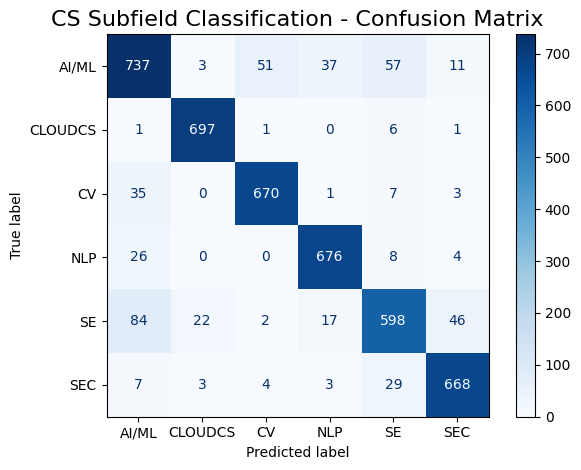

In [12]:
print("\n" + "="*70)
print("TRAINING CS SUBFIELD CLASSIFIER")
print("="*70)

# Prepare CS data
cs_domain_features_aug = cs_domain_features_aug.astype(float)
X_cs = hstack([cs_tfidf_aug, sp.csr_matrix(cs_domain_features_aug.values)])
y_cs = cs_df_aug['subfield'].values

print(f"Feature matrix shape: {X_cs.shape}")
print(f"Labels: {np.unique(y_cs)}")

# Train-test split
X_train_cs, X_test_cs, y_train_cs, y_test_cs = train_test_split(
    X_cs, y_cs, test_size=0.2, random_state=42, stratify=y_cs
)

# Label encoding
cs_label_encoder = LabelEncoder()
y_train_cs_encoded = cs_label_encoder.fit_transform(y_train_cs)
y_test_cs_encoded = cs_label_encoder.transform(y_test_cs)

# Best parameters from v6.0
cs_params = {
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.85,
    'colsample_bytree': 0.85,
    'gamma': 0.1,
    'reg_alpha': 0.1,
    'reg_lambda': 1.5,
    'min_child_weight': 3
}

# Train model
print("\nTraining CS XGBoost model...")
cs_model = XGBClassifier(
    **cs_params,
    objective='multi:softprob',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

cs_model.fit(X_train_cs, y_train_cs_encoded)

# Evaluate
y_pred_cs_encoded = cs_model.predict(X_test_cs)
y_pred_cs = cs_label_encoder.inverse_transform(y_pred_cs_encoded)

cs_accuracy = accuracy_score(y_test_cs, y_pred_cs)
cs_f1 = f1_score(y_test_cs, y_pred_cs, average='macro')

print(f"\n{'='*50}")
print(f"CS CLASSIFIER RESULTS")
print(f"{'='*50}")
print(f"Accuracy: {cs_accuracy:.4f} ({cs_accuracy*100:.2f}%)")
print(f"Macro F1: {cs_f1:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_cs, y_pred_cs, digits=4))

# Confusion matrix
plt.figure(figsize=(10, 8))
cm_cs = confusion_matrix(y_test_cs, y_pred_cs, labels=cs_label_encoder.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cs, display_labels=cs_label_encoder.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('CS Subfield Classification - Confusion Matrix', fontsize=16)
plt.tight_layout()
plt.show()



TRAINING IS SUBFIELD CLASSIFIER
Feature matrix shape: (14416, 11550)
Labels: ['BPM' 'DT' 'GOV' 'HIS' 'KM']

Training IS XGBoost model...

IS CLASSIFIER RESULTS
Accuracy: 0.8339 (83.39%)
Macro F1: 0.8361

Classification Report:
              precision    recall  f1-score   support

         BPM     0.8704    0.8656    0.8680       543
          DT     0.7827    0.7928    0.7877       695
         GOV     0.8628    0.8819    0.8723       542
         HIS     0.9315    0.9400    0.9357       550
          KM     0.7326    0.7022    0.7171       554

    accuracy                         0.8339      2884
   macro avg     0.8360    0.8365    0.8361      2884
weighted avg     0.8330    0.8339    0.8334      2884



<Figure size 1000x800 with 0 Axes>

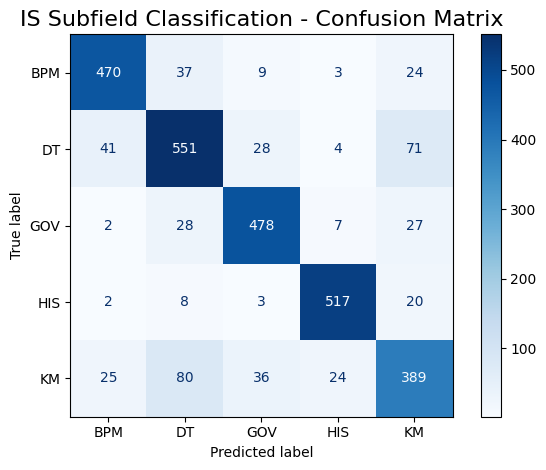

In [13]:
print("\n" + "="*70)
print("TRAINING IS SUBFIELD CLASSIFIER")
print("="*70)

# Prepare IS data
is_domain_features_aug = is_domain_features_aug.astype(float)
X_is = hstack([is_tfidf_aug, sp.csr_matrix(is_domain_features_aug.values)])
y_is = is_df_aug['subfield'].values

print(f"Feature matrix shape: {X_is.shape}")
print(f"Labels: {np.unique(y_is)}")

# Train-test split
X_train_is, X_test_is, y_train_is, y_test_is = train_test_split(
    X_is, y_is, test_size=0.2, random_state=42, stratify=y_is
)

# Label encoding
is_label_encoder = LabelEncoder()
y_train_is_encoded = is_label_encoder.fit_transform(y_train_is)
y_test_is_encoded = is_label_encoder.transform(y_test_is)

# Train model
print("\nTraining IS XGBoost model...")
is_model = XGBClassifier(
    **cs_params,  # Use same params as CS
    objective='multi:softprob',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

is_model.fit(X_train_is, y_train_is_encoded)

# Evaluate
y_pred_is_encoded = is_model.predict(X_test_is)
y_pred_is = is_label_encoder.inverse_transform(y_pred_is_encoded)

is_accuracy = accuracy_score(y_test_is, y_pred_is)
is_f1 = f1_score(y_test_is, y_pred_is, average='macro')

print(f"\n{'='*50}")
print(f"IS CLASSIFIER RESULTS")
print(f"{'='*50}")
print(f"Accuracy: {is_accuracy:.4f} ({is_accuracy*100:.2f}%)")
print(f"Macro F1: {is_f1:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_is, y_pred_is, digits=4))

# Confusion matrix
plt.figure(figsize=(10, 8))
cm_is = confusion_matrix(y_test_is, y_pred_is, labels=is_label_encoder.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_is, display_labels=is_label_encoder.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('IS Subfield Classification - Confusion Matrix', fontsize=16)
plt.tight_layout()
plt.show()


TRAINING IT SUBFIELD CLASSIFIER
Feature matrix shape: (2166, 11545)
Labels: ['CLOUDIT' 'DEVOPS' 'EMERGING' 'RISK']
Class distribution:
  CLOUDIT: 518
  DEVOPS: 651
  EMERGING: 499
  RISK: 498

Training IT XGBoost model...

IT CLASSIFIER RESULTS
Accuracy: 0.8848 (88.48%)
Macro F1: 0.8850

Classification Report:
              precision    recall  f1-score   support

     CLOUDIT     0.8416    0.8173    0.8293       104
      DEVOPS     0.9310    0.8308    0.8780       130
    EMERGING     0.8482    0.9500    0.8962       100
        RISK     0.9143    0.9600    0.9366       100

    accuracy                         0.8848       434
   macro avg     0.8838    0.8895    0.8850       434
weighted avg     0.8867    0.8848    0.8840       434



<Figure size 1000x800 with 0 Axes>

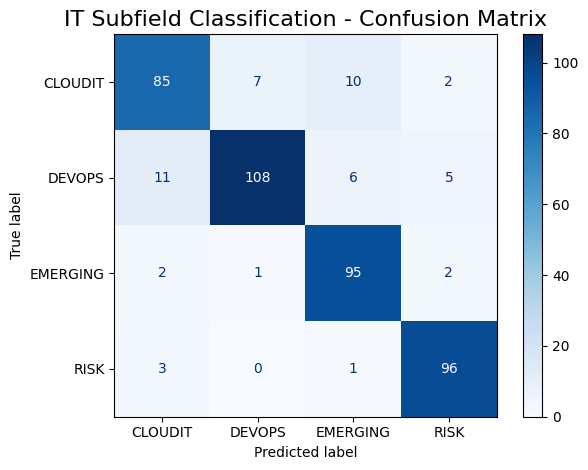

In [14]:
print("\n" + "="*70)
print("TRAINING IT SUBFIELD CLASSIFIER")
print("="*70)

# Prepare IT data
it_domain_features_aug = it_domain_features_aug.astype(float)
X_it = hstack([it_tfidf_aug, sp.csr_matrix(it_domain_features_aug.values)])
y_it = it_df_aug['subfield'].values

print(f"Feature matrix shape: {X_it.shape}")
print(f"Labels: {np.unique(y_it)}")
print(f"Class distribution:")
unique, counts = np.unique(y_it, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  {cls}: {cnt}")

# Train-test split
X_train_it, X_test_it, y_train_it, y_test_it = train_test_split(
    X_it, y_it, test_size=0.2, random_state=42, stratify=y_it
)

# Label encoding
it_label_encoder = LabelEncoder()
y_train_it_encoded = it_label_encoder.fit_transform(y_train_it)
y_test_it_encoded = it_label_encoder.transform(y_test_it)

# Adjusted parameters for IT (smaller dataset)
it_params = {
    'n_estimators': 300,  # Fewer trees
    'max_depth': 5,       # Shallower trees
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0.2,         # More regularization
    'reg_alpha': 0.5,     # More L1 regularization
    'reg_lambda': 2.0,    # More L2 regularization
    'min_child_weight': 5 # Higher minimum samples
}

# Train model
print("\nTraining IT XGBoost model...")
it_model = XGBClassifier(
    **it_params,
    objective='multi:softprob',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

it_model.fit(X_train_it, y_train_it_encoded)

# Evaluate
y_pred_it_encoded = it_model.predict(X_test_it)
y_pred_it = it_label_encoder.inverse_transform(y_pred_it_encoded)

it_accuracy = accuracy_score(y_test_it, y_pred_it)
it_f1 = f1_score(y_test_it, y_pred_it, average='macro')

print(f"\n{'='*50}")
print(f"IT CLASSIFIER RESULTS")
print(f"{'='*50}")
print(f"Accuracy: {it_accuracy:.4f} ({it_accuracy*100:.2f}%)")
print(f"Macro F1: {it_f1:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_it, y_pred_it, digits=4))

# Confusion matrix
plt.figure(figsize=(10, 8))
cm_it = confusion_matrix(y_test_it, y_pred_it, labels=it_label_encoder.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_it, display_labels=it_label_encoder.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('IT Subfield Classification - Confusion Matrix', fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
class SubfieldClassifierV6:
    """Production-ready subfield classifier v6.0"""

    def __init__(self, discipline):
        self.discipline = discipline
        self.feature_extractor = None
        self.tfidf_vectorizers = {}
        self.model = None
        self.label_encoder = None
        self.best_params = None

    def fit(self, texts, labels):
        """Train the complete pipeline"""
        print(f"Training {self.discipline} Subfield Classifier v6.0...")

        # Initialize components
        self.label_encoder = LabelEncoder()
        labels_encoded = self.label_encoder.fit_transform(labels)

        # Preprocess texts
        processed_texts = [preprocess_text(text) for text in texts]

        # Extract domain features
        self.feature_extractor = SubfieldFeatureExtractor(self.discipline)
        domain_feats = self.feature_extractor.extract_features(processed_texts)

        # Create TF-IDF features
        tfidf_feats, self.tfidf_vectorizers, _ = create_tfidf_features(processed_texts, self.discipline)

        # Combine features
        X = hstack([tfidf_feats, sp.csr_matrix(domain_feats.astype(float).values)])

        # Set parameters based on discipline
        if self.discipline == 'IT':
            self.best_params = it_params
        else:
            self.best_params = cs_params

        # Train model
        self.model = XGBClassifier(
            **self.best_params,
            objective='multi:softprob',
            use_label_encoder=False,
            random_state=42,
            n_jobs=-1
        )
        self.model.fit(X, labels_encoded)

        print("Training complete!")

    def predict(self, texts):
        """Predict subfields for new texts"""
        # Preprocess
        processed_texts = [preprocess_text(text) for text in texts]

        # Extract features
        domain_feats = self.feature_extractor.extract_features(processed_texts)

        # TF-IDF features
        tfidf_feats = []
        for name, vec in self.tfidf_vectorizers.items():
            feats = vec.transform(processed_texts)
            tfidf_feats.append(feats)

        # Combine
        X = hstack(tfidf_feats + [sp.csr_matrix(domain_feats.astype(float).values)])

        # Predict
        pred_encoded = self.model.predict(X)
        predictions = self.label_encoder.inverse_transform(pred_encoded)

        return predictions

    def predict_proba(self, texts):
        """Get prediction probabilities"""
        processed_texts = [preprocess_text(text) for text in texts]
        domain_feats = self.feature_extractor.extract_features(processed_texts)

        tfidf_feats = []
        for name, vec in self.tfidf_vectorizers.items():
            feats = vec.transform(processed_texts)
            tfidf_feats.append(feats)

        X = hstack(tfidf_feats + [sp.csr_matrix(domain_feats.astype(float).values)])

        return self.model.predict_proba(X)

    def save(self, filepath):
        """Save the complete pipeline"""
        import joblib
        from datetime import datetime

        pipeline_data = {
            'discipline': self.discipline,
            'feature_extractor': self.feature_extractor,
            'tfidf_vectorizers': self.tfidf_vectorizers,
            'model': self.model,
            'label_encoder': self.label_encoder,
            'best_params': self.best_params,
            'version': '6.0',
            'timestamp': datetime.now().isoformat()
        }

        joblib.dump(pipeline_data, filepath)
        print(f"Model saved to {filepath}")

In [16]:
print("\n" + "="*70)
print("SAVING MODELS AND RESULTS")
print("="*70)

# Create save directories
base_dir = "/content/drive/MyDrive/NLP_Project"
save_dirs = {
    'CS': f"{base_dir}/cs_subfield_classifier_v6.0",
    'IS': f"{base_dir}/is_subfield_classifier_v6.0",
    'IT': f"{base_dir}/it_subfield_classifier_v6.0"
}

for discipline, save_dir in save_dirs.items():
    os.makedirs(save_dir, exist_ok=True)

# Create and save CS pipeline
print("\nSaving CS Subfield Classifier...")
cs_pipeline = SubfieldClassifierV6('CS')
cs_pipeline.feature_extractor = cs_extractor
cs_pipeline.tfidf_vectorizers = cs_vectorizers
cs_pipeline.model = cs_model
cs_pipeline.label_encoder = cs_label_encoder
cs_pipeline.best_params = cs_params
cs_pipeline.save(f"{save_dirs['CS']}/cs_subfield_classifier_v6.0_pipeline.pkl")

# Save CS components
joblib.dump(cs_model, f"{save_dirs['CS']}/xgb_model_v6.0.pkl")
joblib.dump(cs_vectorizers, f"{save_dirs['CS']}/tfidf_vectorizers_v6.0.pkl")
joblib.dump(cs_extractor, f"{save_dirs['CS']}/feature_extractor_v6.0.pkl")
joblib.dump(cs_label_encoder, f"{save_dirs['CS']}/label_encoder_v6.0.pkl")

# Create and save IS pipeline
print("\nSaving IS Subfield Classifier...")
is_pipeline = SubfieldClassifierV6('IS')
is_pipeline.feature_extractor = is_extractor
is_pipeline.tfidf_vectorizers = is_vectorizers
is_pipeline.model = is_model
is_pipeline.label_encoder = is_label_encoder
is_pipeline.best_params = cs_params
is_pipeline.save(f"{save_dirs['IS']}/is_subfield_classifier_v6.0_pipeline.pkl")

# Save IS components
joblib.dump(is_model, f"{save_dirs['IS']}/xgb_model_v6.0.pkl")
joblib.dump(is_vectorizers, f"{save_dirs['IS']}/tfidf_vectorizers_v6.0.pkl")
joblib.dump(is_extractor, f"{save_dirs['IS']}/feature_extractor_v6.0.pkl")
joblib.dump(is_label_encoder, f"{save_dirs['IS']}/label_encoder_v6.0.pkl")

# Create and save IT pipeline
print("\nSaving IT Subfield Classifier...")
it_pipeline = SubfieldClassifierV6('IT')
it_pipeline.feature_extractor = it_extractor
it_pipeline.tfidf_vectorizers = it_vectorizers
it_pipeline.model = it_model
it_pipeline.label_encoder = it_label_encoder
it_pipeline.best_params = it_params
it_pipeline.save(f"{save_dirs['IT']}/it_subfield_classifier_v6.0_pipeline.pkl")

# Save IT components
joblib.dump(it_model, f"{save_dirs['IT']}/xgb_model_v6.0.pkl")
joblib.dump(it_vectorizers, f"{save_dirs['IT']}/tfidf_vectorizers_v6.0.pkl")
joblib.dump(it_extractor, f"{save_dirs['IT']}/feature_extractor_v6.0.pkl")
joblib.dump(it_label_encoder, f"{save_dirs['IT']}/label_encoder_v6.0.pkl")

# Save results summary
results_summary = {
    'version': '6.0',
    'timestamp': datetime.now().isoformat(),
    'CS': {
        'original_samples': len(cs_df),
        'augmented_samples': len(cs_df_aug),
        'accuracy': float(cs_accuracy),
        'macro_f1': float(cs_f1),
        'classes': cs_label_encoder.classes_.tolist(),
        'features': X_cs.shape[1],
        'tfidf_features': cs_tfidf_aug.shape[1],
        'domain_features': cs_domain_features_aug.shape[1]
    },
    'IS': {
        'original_samples': len(is_df),
        'augmented_samples': len(is_df_aug),
        'accuracy': float(is_accuracy),
        'macro_f1': float(is_f1),
        'classes': is_label_encoder.classes_.tolist(),
        'features': X_is.shape[1],
        'tfidf_features': is_tfidf_aug.shape[1],
        'domain_features': is_domain_features_aug.shape[1]
    },
    'IT': {
        'original_samples': len(it_df),
        'augmented_samples': len(it_df_aug),
        'accuracy': float(it_accuracy),
        'macro_f1': float(it_f1),
        'classes': it_label_encoder.classes_.tolist(),
        'features': X_it.shape[1],
        'tfidf_features': it_tfidf_aug.shape[1],
        'domain_features': it_domain_features_aug.shape[1]
    }
}

# Save as JSON
import json
with open(f"{base_dir}/subfield_classifiers_v6.0_results.json", 'w') as f:
    json.dump(results_summary, f, indent=2)

# Final summary
print("\n" + "="*70)
print("FINAL RESULTS SUMMARY - Subfield Classifiers v6.0")
print("="*70)

for discipline in ['CS', 'IS', 'IT']:
    res = results_summary[discipline]
    print(f"\n{discipline} Subfield Classifier:")
    print(f"  Samples: {res['original_samples']:,} → {res['augmented_samples']:,} (augmented)")
    print(f"  Features: {res['tfidf_features']} TF-IDF + {res['domain_features']} domain = {res['features']} total")
    print(f"  Accuracy: {res['accuracy']:.4f} ({res['accuracy']*100:.2f}%)")
    print(f"  Macro F1: {res['macro_f1']:.4f}")
    print(f"  Classes: {', '.join(res['classes'])}")

print("\n" + "="*70)
print("✅ All subfield classifiers saved successfully!")
print("="*70)


SAVING MODELS AND RESULTS

Saving CS Subfield Classifier...
Model saved to /content/drive/MyDrive/NLP_Project/cs_subfield_classifier_v6.0/cs_subfield_classifier_v6.0_pipeline.pkl

Saving IS Subfield Classifier...
Model saved to /content/drive/MyDrive/NLP_Project/is_subfield_classifier_v6.0/is_subfield_classifier_v6.0_pipeline.pkl

Saving IT Subfield Classifier...
Model saved to /content/drive/MyDrive/NLP_Project/it_subfield_classifier_v6.0/it_subfield_classifier_v6.0_pipeline.pkl

FINAL RESULTS SUMMARY - Subfield Classifiers v6.0

CS Subfield Classifier:
  Samples: 14,910 → 22,571 (augmented)
  Features: 11500 TF-IDF + 55 domain = 11555 total
  Accuracy: 0.8961 (89.61%)
  Macro F1: 0.8993
  Classes: AI/ML, CLOUDCS, CV, NLP, SE, SEC

IS Subfield Classifier:
  Samples: 10,460 → 14,416 (augmented)
  Features: 11500 TF-IDF + 50 domain = 11550 total
  Accuracy: 0.8339 (83.39%)
  Macro F1: 0.8361
  Classes: BPM, DT, GOV, HIS, KM

IT Subfield Classifier:
  Samples: 1,574 → 2,166 (augmented)


In [17]:
print("\n" + "="*70)
print("TESTING COMPLETE THREE-TIER PIPELINE")
print("="*70)

# Example test abstracts
test_abstracts = [
    # CS - AI/ML example
    "This paper presents a novel deep learning approach for image classification using convolutional neural networks. We propose an enhanced architecture that improves accuracy on the ImageNet dataset by incorporating attention mechanisms and residual connections. Our model achieves state-of-the-art performance with 95% accuracy.",

    # IS - DT example
    "This study examines digital transformation initiatives in Fortune 500 companies. Through case studies and interviews with CIOs, we identify key success factors for digital strategy implementation. Our findings reveal that organizational culture and leadership commitment are critical for successful digital transformation.",

    # IT - CLOUD example
    "This paper describes the implementation of a hybrid cloud infrastructure for enterprise applications. We detail the migration process from on-premises servers to AWS, including security configurations, cost optimization strategies, and performance monitoring. The solution reduced operational costs by 40%."
]

print("Test abstracts:")
for i, abstract in enumerate(test_abstracts):
    print(f"\n{i+1}. {abstract[:100]}...")

# First,use the discipline classifier (v6.0) to classify the discipline
# Then use the appropriate subfield classifier
# Finally use the methodology classifier (v6.0)

# For this test, we'll just demonstrate the subfield classifiers
print("\n\nSubfield Classification Results:")
print("-" * 50)

# Test CS classifier
cs_test = [test_abstracts[0]]
cs_pred = cs_pipeline.predict(cs_test)
cs_proba = cs_pipeline.predict_proba(cs_test)
print(f"\nCS Abstract → Predicted: {cs_pred[0]}")
print(f"Confidence scores: {dict(zip(cs_label_encoder.classes_, cs_proba[0].round(3)))}")

# Test IS classifier
is_test = [test_abstracts[1]]
is_pred = is_pipeline.predict(is_test)
is_proba = is_pipeline.predict_proba(is_test)
print(f"\nIS Abstract → Predicted: {is_pred[0]}")
print(f"Confidence scores: {dict(zip(is_label_encoder.classes_, is_proba[0].round(3)))}")

# Test IT classifier
it_test = [test_abstracts[2]]
it_pred = it_pipeline.predict(it_test)
it_proba = it_pipeline.predict_proba(it_test)
print(f"\nIT Abstract → Predicted: {it_pred[0]}")
print(f"Confidence scores: {dict(zip(it_label_encoder.classes_, it_proba[0].round(3)))}")

print("\n" + "="*70)
print("🎉 SUBFIELD CLASSIFIERS V6.0 COMPLETE!")
print("="*70)
print("\nNext steps:")
print("1. Integrate with discipline classifier v6.0 (94.77% accuracy)")
print("2. Add methodology classifier v6.0 (91.87% accuracy)")
print("3. Create unified pipeline for complete paper classification")
print("="*70)


TESTING COMPLETE THREE-TIER PIPELINE
Test abstracts:

1. This paper presents a novel deep learning approach for image classification using convolutional neur...

2. This study examines digital transformation initiatives in Fortune 500 companies. Through case studie...

3. This paper describes the implementation of a hybrid cloud infrastructure for enterprise applications...


Subfield Classification Results:
--------------------------------------------------

CS Abstract → Predicted: CV
Confidence scores: {'AI/ML': np.float32(0.1), 'CLOUDCS': np.float32(0.005), 'CV': np.float32(0.79), 'NLP': np.float32(0.011), 'SE': np.float32(0.091), 'SEC': np.float32(0.003)}

IS Abstract → Predicted: DT
Confidence scores: {'BPM': np.float32(0.015), 'DT': np.float32(0.941), 'GOV': np.float32(0.002), 'HIS': np.float32(0.006), 'KM': np.float32(0.037)}

IT Abstract → Predicted: CLOUDIT
Confidence scores: {'CLOUDIT': np.float32(0.739), 'DEVOPS': np.float32(0.036), 'EMERGING': np.float32(0.017), 'RISK': n